# AI Atmosphere Model (S2S)

**Goal**: Train a diffusion-based 3D UNet to predict next-day atmospheric state from multi-source inputs, all on a HEALPix grid.

**Pipeline**:
1. Install dependencies
2. Load ERA5 atmosphere + land data from GCS Zarr
3. Load GODAS ocean data (GRIB)
4. Load static fields (land-sea mask, topography)
5. Regrid everything to a common 0.25-degree lat-lon grid
6. Fill NaNs, compute daily means, apply min-max normalization
7. Project to HEALPix (level 6)
8. Build X(t) and Y(t+1) tensors
9. Define diffusion model and train

**Input X(t)** — 20 channels: 7 atmos surface + 7 pressure-level + 2 land + 2 ocean + 2 static

**Target Y(t+1)** — 14 channels: 7 atmos surface + 7 pressure-level (next day)

**Tensor shape**: `[batch, channels, 12, 64, 64]` — 12 HEALPix faces at nside=64

---
## Step 1: Install Dependencies

In [1]:
!pip install -q uv
!uv pip install --system -q "xarray[complete]" zarr gcsfs dask pygrib diffusers accelerate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.4/23.4 MB 76.8 MB/s eta 0:00:00


In [2]:
!nvcc -V

nvcc: NVIDIA (R) Cuda compiler driver
Copyright (c) 2005-2025 NVIDIA Corporation
Built on Fri_Feb_21_20:23:50_PST_2025
Cuda compilation tools, release 12.8, V12.8.93
Build cuda_12.8.r12.8/compiler.35583870_0


In [3]:
!pip install --no-build-isolation https://github.com/NVlabs/earth2grid/archive/refs/tags/v2025.7.1.tar.gz
# Verify
import earth2grid
print("earth2grid imported successfully")

     \ 185.9 kB 4.6 MB/s 0:00:00
  Preparing metadata (pyproject.toml) ... done
  Created wheel for earth2grid: filename=earth2grid-2025.7.1+torch210-cp312-cp312-linux_x86_64.whl size=7996802 sha256=a9ba41942e94a094dbeb2d729bb1140db8af0f7daa4071db6da1fcbb67a9162d
  Stored in directory: /tmp/pip-ephem-wheel-cache-j8v8wzww/wheels/c2/6c/2d/1c63e49a29c834b1c6ac717cb579251de50f1e40db202855dd
Successfully built earth2grid
earth2grid imported successfully


In [4]:
import os, gc, json, datetime
import numpy as np
import xarray as xr
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import earth2grid
import matplotlib.pyplot as plt

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

Device: cuda


---
## Step 2: Load ERA5 Atmosphere Data from GCS Zarr

In [5]:
ERA5_ZARR = "gs://gcp-public-data-arco-era5/ar/full_37-1h-0p25deg-chunk-1.zarr-v3"
ds = xr.open_zarr(ERA5_ZARR, consolidated=True, storage_options={"token": "anon"})
print(f"ERA5 dataset loaded: {len(ds.data_vars)} variables")

ERA5 dataset loaded: 273 variables


In [6]:
# Resolve variable names (ERA5 naming can vary)
ATMOS_CANDIDATES = {
    "2m_temperature":          ["2m_temperature", "t2m"],
    "10m_u_component_of_wind": ["10m_u_component_of_wind", "u10"],
    "10m_v_component_of_wind": ["10m_v_component_of_wind", "v10"],
    "total_column_water_vapour": ["total_column_water_vapour", "tcwv",
                                   "total_column_integrated_water_vapour"],
    "mean_sea_level_pressure": ["mean_sea_level_pressure", "msl", "mslp"],
    "top_net_thermal_radiation": ["top_net_thermal_radiation", "ttr"],
    "toa_incident_solar_radiation": ["toa_incident_solar_radiation", "tisr",
                                      "toa_insolation",
                                      "top_of_atmosphere_incident_solar_radiation"],
    "geopotential":  ["geopotential", "z"],
    "temperature":   ["temperature", "t"],
}

LAND_CANDIDATES = {
    "volumetric_soil_water_layer_1": ["swvl1", "volumetric_soil_water_layer_1"],
    "soil_temperature_level_1":      ["stl1", "soil_temperature_level_1"],
}

def pick_var(ds, candidates):
    for c in candidates:
        if c in ds.data_vars:
            return c
    return None

# Build atmosphere dataset
atmos_var_names = []
for key, cands in ATMOS_CANDIDATES.items():
    name = pick_var(ds, cands)
    if name:
        atmos_var_names.append(name)
        print(f"  {key} -> {name}")
    else:
        print(f"  {key} -> NOT FOUND")

ds_atmos = ds[atmos_var_names]

# Build land dataset
land_var_names = []
for key, cands in LAND_CANDIDATES.items():
    name = pick_var(ds, cands)
    if name:
        land_var_names.append(name)
        print(f"  {key} -> {name}")
    else:
        print(f"  {key} -> NOT FOUND")

ds_land = ds[land_var_names]

print(f"\nAtmos vars: {list(ds_atmos.data_vars)}")
print(f"Land vars:  {list(ds_land.data_vars)}")

  2m_temperature -> 2m_temperature
  10m_u_component_of_wind -> 10m_u_component_of_wind
  10m_v_component_of_wind -> 10m_v_component_of_wind
  total_column_water_vapour -> total_column_water_vapour
  mean_sea_level_pressure -> mean_sea_level_pressure
  top_net_thermal_radiation -> top_net_thermal_radiation
  toa_incident_solar_radiation -> toa_incident_solar_radiation
  geopotential -> geopotential
  temperature -> temperature
  volumetric_soil_water_layer_1 -> volumetric_soil_water_layer_1
  soil_temperature_level_1 -> soil_temperature_level_1

Atmos vars: ['2m_temperature', '10m_u_component_of_wind', '10m_v_component_of_wind', 'total_column_water_vapour', 'mean_sea_level_pressure', 'top_net_thermal_radiation', 'toa_incident_solar_radiation', 'geopotential', 'temperature']
Land vars:  ['volumetric_soil_water_layer_1', 'soil_temperature_level_1']


---
## Step 3: Load GODAS Ocean Data

Download a pentad GODAS GRIB file and extract potential temperature + salinity.

In [7]:
!pip install pygrib==2.1.6

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.6/18.6 MB 45.4 MB/s eta 0:00:00
  Attempting uninstall: pygrib
    Found existing installation: pygrib 2.1.8
    Uninstalling pygrib-2.1.8:
      Successfully uninstalled pygrib-2.1.8


In [8]:
!wget -q https://ftp.cpc.ncep.noaa.gov/godas/pentad/2025/godas.P.20250105.grb
print("GODAS file downloaded.")

GODAS file downloaded.


In [9]:
import pygrib

file_name = "godas.P.20250105.grb"
grbs = pygrib.open(file_name)

temperature_da_list = []
salinity_da_list = []

for grb in grbs:
    data = grb.values
    lats, lons = grb.latlons()
    lat_1d = lats[:, 0]
    lon_1d = lons[0, :]

    da = xr.DataArray(
        data,
        dims=["lat", "lon"],
        coords={"lat": lat_1d, "lon": lon_1d},
    )

    if "Potential temperature" in grb.name:
        da = da.assign_coords(level=grb.level)
        temperature_da_list.append(da)
    elif "Salinity" in grb.name:
        da = da.assign_coords(level=grb.level)
        salinity_da_list.append(da)

grbs.close()

# Combine into a single dataset
temp_da = xr.concat(temperature_da_list, dim="level")
sal_da  = xr.concat(salinity_da_list, dim="level")

ds_ocean = xr.Dataset({
    "potential_temperature": temp_da,
    "salinity": sal_da,
})

print(f"Ocean dataset: {ds_ocean}")
print(f"  Levels: {ds_ocean.level.values[:5]}... ({len(ds_ocean.level)} total)")

Ocean dataset: <xarray.Dataset> Size: 96MB
Dimensions:                (lat: 418, lon: 360, level: 40)
Coordinates:
  * lat                    (lat) float64 3kB -74.5 -74.17 -73.83 ... 64.03 64.5
  * lon                    (lon) float64 3kB 0.5 1.5 2.5 ... 357.5 358.5 359.5
  * level                  (level) int64 320B 5 15 25 35 ... 3016 3483 3972 4478
Data variables:
    potential_temperature  (level, lat, lon) float64 48MB nan nan ... nan nan
    salinity               (level, lat, lon) float64 48MB nan nan ... nan nan
  Levels: [ 5 15 25 35 45]... (40 total)


---
## Step 4: Load Static Fields (Land-Sea Mask + Topography)

In [10]:
# Download land-sea mask
!wget -q https://pmm.nasa.gov/sites/default/files/downloads/IMERG_land_sea_mask.nc.gz
!gunzip -f IMERG_land_sea_mask.nc.gz

# Download topography
!wget -q https://d1qb6yzwaaq4he.cloudfront.net/data/gmted2010/GMTED2010_15n060_0250deg.nc

ds_imerg_land_sea_mask = xr.open_dataset("IMERG_land_sea_mask.nc")

ds_topo_raw = xr.open_dataset("GMTED2010_15n060_0250deg.nc")
# Shift longitude from [-180, 180] to [0, 360] to match ERA5
ds_topo_raw["longitude"] = ds_topo_raw["longitude"] + 180

print("Land-sea mask:", ds_imerg_land_sea_mask)
print("\nTopography:", ds_topo_raw)

Land-sea mask: <xarray.Dataset> Size: 26MB
Dimensions:      (lat: 1800, lon: 3602)
Coordinates:
  * lat          (lat) float64 14kB -89.95 -89.85 -89.75 ... 89.75 89.85 89.95
  * lon          (lon) float64 29kB -0.05 0.05 0.15 0.25 ... 359.9 360.0 360.1
Data variables:
    landseamask  (lat, lon) float32 26MB ...

Topography: <xarray.Dataset> Size: 8MB
Dimensions:           (latitude: 720, nbounds: 2, longitude: 1440)
Coordinates:
  * latitude          (latitude) float32 3kB -89.88 -89.62 ... 89.62 89.88
  * nbounds           (nbounds) int16 4B 0 1
  * longitude         (longitude) float32 6kB 0.125 0.375 0.625 ... 359.6 359.9
Data variables:
    latitude_bounds   (latitude, nbounds) float32 6kB ...
    longitude_bounds  (longitude, nbounds) float32 12kB ...
    elevation         (latitude, longitude) int16 2MB ...
    elevation_stddev  (latitude, longitude) int16 2MB ...
    elevation_max     (latitude, longitude) int16 2MB ...
    elevation_min     (latitude, longitude) int16 2MB ...

---
## Step 5: Regrid Ocean + Static Fields to 0.25-degree Atmos Grid

In [11]:
# Use atmosphere grid as reference
# Load a single snapshot to get lat/lon coordinates
sample_atmos = ds_atmos.isel(time=0)
target_lat = sample_atmos.latitude
target_lon = sample_atmos.longitude
print(f"Reference grid: {len(target_lat)} lats x {len(target_lon)} lons")

# Regrid ocean to atmos grid
ds_ocean_renamed = ds_ocean.rename({"lat": "latitude", "lon": "longitude"})
ds_ocean_regridded = ds_ocean_renamed.interp(
    latitude=target_lat, longitude=target_lon, method="linear"
)
# Add a dummy time coordinate for consistency with the pipeline
ds_ocean_regridded = ds_ocean_regridded.expand_dims(
    time=[np.datetime64("2025-01-05")]
)

# Regrid land-sea mask
ds_mask_regridded = ds_imerg_land_sea_mask.interp(
    lat=target_lat, lon=target_lon, method="linear"
)

# Regrid topography
ds_topo_regridded = ds_topo_raw.interp(
    latitude=target_lat, longitude=target_lon, method="linear"
)

print("Ocean regridded:",  ds_ocean_regridded.dims)
print("Mask regridded:",   ds_mask_regridded.dims)
print("Topo regridded:",   ds_topo_regridded.dims)

Reference grid: 721 lats x 1440 lons
Ocean regridded: FrozenMappingWarningOnValuesAccess({'time': 1, 'level': 40, 'latitude': 721, 'longitude': 1440})
Mask regridded: FrozenMappingWarningOnValuesAccess({'latitude': 721, 'longitude': 1440})
Topo regridded: FrozenMappingWarningOnValuesAccess({'latitude': 721, 'nbounds': 2, 'longitude': 1440})


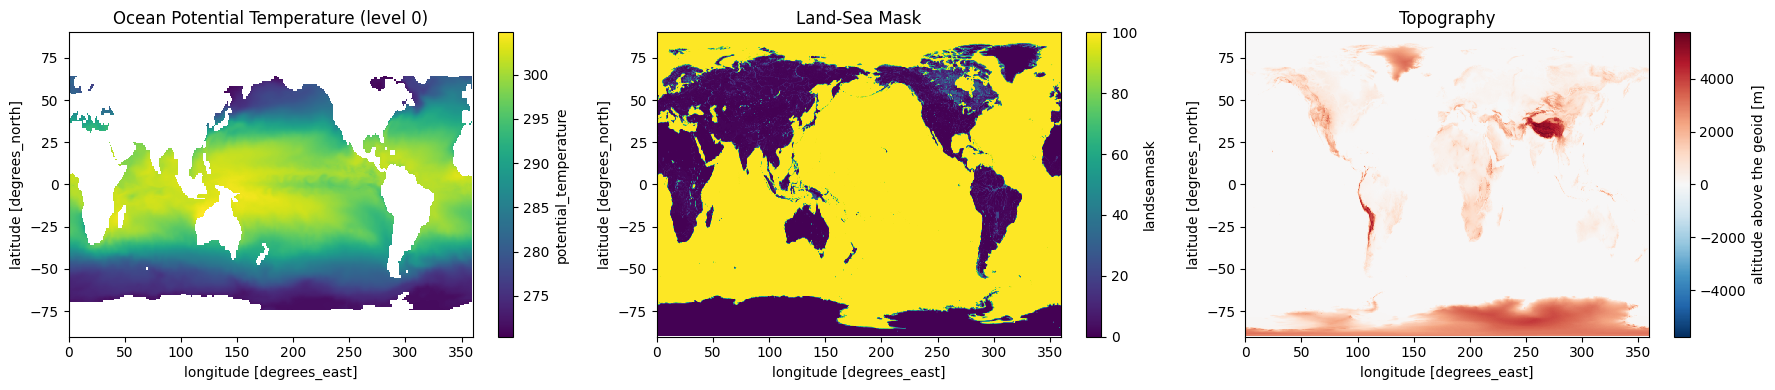

In [12]:
# Quick sanity plots
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
ds_ocean_regridded.isel(level=0, time=0).potential_temperature.plot(ax=axes[0])
axes[0].set_title("Ocean Potential Temperature (level 0)")
ds_mask_regridded.landseamask.plot(ax=axes[1])
axes[1].set_title("Land-Sea Mask")
ds_topo_regridded.elevation.plot(ax=axes[2])
axes[2].set_title("Topography")
plt.tight_layout()
plt.show()

---
## Step 6: Helper Functions

Utilities for lat sorting, daily means, NaN filling, normalization, and HEALPix conversion.

In [13]:
# ==================== CONFIGURATION ====================

HPX_LEVEL = 6
NSIDE = 2 ** HPX_LEVEL  # 64

CONVERT_GPH_TO_HEIGHT = True
G0 = 9.80665

# Min-max normalization stats (computed from ERA5 / GODAS)
NORM = {
    # Atmos 2D (surface)
    "2m_temperature":           {"min": 188.023, "max": 326.906},
    "10m_u_component_of_wind":  {"min": -281.124, "max": 132.541},
    "10m_v_component_of_wind":  {"min": -159.218, "max": 166.600},
    "mean_sea_level_pressure":  {"min": 89991.063, "max": 109923.438},
    "tcwv":                     {"min": 0.050, "max": 85.455},
    "top_net_thermal_radiation":    {"min": -1313311.5, "max": -281460.031},
    "toa_incident_solar_radiation": {"min": -0.25, "max": 2014404.625},

    # Pressure-level slices (geopotential height in m, temperature in K)
    "z_1000": {"min": -6174.143, "max": 4626.292},
    "z_850":  {"min": 5940.180,  "max": 17029.006},
    "z_700":  {"min": 20248.557, "max": 32538.490},
    "z_500":  {"min": 43559.191, "max": 58915.500},
    "z_300":  {"min": 75701.602, "max": 96554.875},
    "z_250":  {"min": 86646.961, "max": 109212.938},
    "t_850":  {"min": 216.382,   "max": 310.778},

    # Land
    "volumetric_soil_water_layer_1": {"min": -0.031, "max": 0.790},
    "soil_temperature_level_1":      {"min": 196.464, "max": 340.485},

    # Ocean (GODAS level 0)
    "potential_temperature": {"min": 267.408, "max": 306.139},
    "salinity":             {"min": 0.007,   "max": 0.046},

    # Static
    "landseamask": {"min": 0.0,    "max": 100.0},
    "elevation":   {"min": -81.25, "max": 5764.0},
}

In [14]:
# ==================== HELPER FUNCTIONS ====================

def norm_minmax(arr, vname, eps=1e-12):
    """Min-max normalize using NORM stats."""
    vmin = NORM[vname]["min"]
    vmax = NORM[vname]["max"]
    return (arr - vmin) / (vmax - vmin + eps)


def ensure_lat_ascending(ds, lat_name="latitude"):
    """Sort latitude ascending (required for earth2grid)."""
    if lat_name in ds.coords:
        lat = ds[lat_name].values
        if lat[0] > lat[-1]:
            ds = ds.sortby(lat_name)
    return ds


def daily_mean(ds):
    return ds.resample(time="1D").mean()


def pick_single_day(ds_daily, day_str):
    """Select a single day from a daily-mean dataset."""
    target = np.datetime64(day_str)
    try:
        out = ds_daily.sel(time=target)
    except Exception:
        out = ds_daily.sel(time=target, method="nearest")
    if "time" in out.dims and out.sizes["time"] > 1:
        out = out.isel(time=0)
    return out


def ocean_nearest_prior(ds_ocean, target_time):
    """Select the most recent ocean snapshot before target_time."""
    ds_ocean = ds_ocean.sortby("time")
    return ds_ocean.sel(time=np.datetime64(target_time), method="pad")


def standardize_latlon(ds):
    """Rename lat/lon dims/coords to latitude/longitude."""
    ds2 = ds.copy()
    rename = {}
    if "lat" in ds2.dims and "latitude" not in ds2.dims:
        rename["lat"] = "latitude"
    if "lon" in ds2.dims and "longitude" not in ds2.dims:
        rename["lon"] = "longitude"
    if rename:
        ds2 = ds2.rename(rename)
    rename_c = {}
    if "lat" in ds2.coords and "latitude" not in ds2.coords:
        rename_c["lat"] = "latitude"
    if "lon" in ds2.coords and "longitude" not in ds2.coords:
        rename_c["lon"] = "longitude"
    if rename_c:
        ds2 = ds2.rename(rename_c)
    return ds2


def fill_latlon_nans_2d(da2d):
    """Fill NaNs via linear interpolation along lat then lon."""
    da2d = da2d.interpolate_na(dim="latitude", method="linear", fill_value="extrapolate")
    da2d = da2d.interpolate_na(dim="longitude", method="linear", fill_value="extrapolate")
    return da2d


def to_2d(da):
    """Squeeze a DataArray down to (latitude, longitude)."""
    if "time" in da.dims:
        if da.sizes["time"] > 1:
            da = da.isel(time=0)
        else:
            da = da.squeeze("time", drop=True)
    return da


def resolve_var(ds, candidates):
    """Find the first matching variable name in a dataset."""
    for c in candidates:
        if c in ds.data_vars:
            return c
    raise KeyError(f"None of {candidates} found in dataset.")


def select_pressure_level(da, hpa):
    """Select a single pressure level and squeeze to 2D."""
    for dim_name in ["isobaricInhPa", "level", "pressure_level"]:
        if dim_name in da.dims:
            da_sel = da.sel({dim_name: hpa}, method="nearest")
            da_sel = da_sel.squeeze(drop=True) if dim_name in da_sel.dims else da_sel
            return to_2d(da_sel)
    raise ValueError(f"No pressure dim found in {da.name}, dims={da.dims}")


print("Helpers defined.")

Helpers defined.


---
## Step 7: Fill NaNs in Static Fields

In [15]:
from scipy.spatial import cKDTree

def fill_nan_nearest_2d(da2d):
    """
    Fill NaNs with nearest non-NaN value using KDTree in index space.
    For static fields where linear interp may leave coastal NaNs.
    """
    da = da2d.squeeze(drop=True).copy()
    arr = da.values
    nan_mask = ~np.isfinite(arr)
    if not nan_mask.any():
        return da

    rows, cols = np.indices(arr.shape)
    valid = np.isfinite(arr)
    tree = cKDTree(np.column_stack([rows[valid], cols[valid]]))
    _, idx = tree.query(np.column_stack([rows[nan_mask], cols[nan_mask]]))
    arr[nan_mask] = arr[valid][idx]
    da.values = arr
    return da

# Standardize coordinate names
ds_mask = standardize_latlon(ds_mask_regridded)
ds_topo = standardize_latlon(ds_topo_regridded)

# Fill NaNs in static fields
topo_da = ds_topo["elevation"].squeeze(drop=True)
mask_da = ds_mask["landseamask"].squeeze(drop=True)

print(f"Topo NaNs before: {int(np.isnan(topo_da.values).sum())}")
print(f"Mask NaNs before: {int(np.isnan(mask_da.values).sum())}")

topo_filled = fill_nan_nearest_2d(topo_da)
mask_filled = fill_nan_nearest_2d(mask_da)

print(f"Topo NaNs after:  {int(np.isnan(topo_filled.values).sum())}")
print(f"Mask NaNs after:  {int(np.isnan(mask_filled.values).sum())}")

# Store back
ds_topo = ds_topo.copy()
ds_mask = ds_mask.copy()
ds_topo["elevation"] = topo_filled
ds_mask["landseamask"] = mask_filled

Topo NaNs before: 3599
Mask NaNs before: 2880
Topo NaNs after:  0
Mask NaNs after:  0


---
## Step 8: Build HEALPix Regridder

In [25]:
ds_atmos.sel(time='1900-01-01T01')

<xarray.Dataset> Size: 336MB
Dimensions:                       (latitude: 721, longitude: 1440, level: 37)
Coordinates:
  * latitude                      (latitude) float32 3kB 90.0 89.75 ... -90.0
  * longitude                     (longitude) float32 6kB 0.0 0.25 ... 359.8
  * level                         (level) int64 296B 1 2 3 5 ... 950 975 1000
    time                          datetime64[ns] 8B 1900-01-01T01:00:00
Data variables:
    2m_temperature                (latitude, longitude) float32 4MB dask.array<chunksize=(721, 1440), meta=np.ndarray>
    10m_u_component_of_wind       (latitude, longitude) float32 4MB dask.array<chunksize=(721, 1440), meta=np.ndarray>
    10m_v_component_of_wind       (latitude, longitude) float32 4MB dask.array<chunksize=(721, 1440), meta=np.ndarray>
    total_column_water_vapour     (latitude, longitude) float32 4MB dask.array<chunksize=(721, 1440), meta=np.ndarray>
    mean_sea_level_pressure       (latitude, longitude) float32 4MB dask.array<chunksize=(721, 1440), meta=np.ndarray>
    top_net_thermal_radiation     (latitude, longitude) float32 4MB dask.array<chunksize=(721, 1440), meta=np.ndarray>
    toa_incident_solar_radiation  (latitude, longitude) float32 4MB dask.array<chunksize=(721, 1440), meta=np.ndarray>
    geopotential                  (level, latitude, longitude) float32 154MB dask.array<chunksize=(37, 721, 1440), meta=np.ndarray>
    temperature                   (level, latitude, longitude) float32 154MB dask.array<chunksize=(37, 721, 1440), meta=np.ndarray>
Attributes:
    last_updated:           2026-03-11 01:58:50.579409+00:00
    valid_time_start:       1940-01-01
    valid_time_stop:        2025-11-30
    valid_time_stop_era5t:  2026-03-05

In [27]:
test_var = list(sample_var.data_vars)[0]

In [29]:
test_var

'2m_temperature'

In [32]:
ds_atmos.sel(time='2010-01-01T01')[test_var].compute()

<xarray.DataArray '2m_temperature' (latitude: 721, longitude: 1440)> Size: 4MB
array([[248.61377, 248.61377, 248.61377, ..., 248.61377, 248.61377,
        248.61377],
       [248.1851 , 248.1851 , 248.18665, ..., 248.17896, 248.1805 ,
        248.18204],
       [247.77335, 247.77487, 247.77641, ..., 247.76105, 247.76413,
        247.76874],
       ...,
       [247.01128, 247.01282, 247.01282, ..., 247.00821, 247.00821,
        247.01128],
       [246.8392 , 246.8392 , 246.8392 , ..., 246.83766, 246.83766,
        246.8392 ],
       [246.36906, 246.36906, 246.36906, ..., 246.36906, 246.36906,
        246.36906]], dtype=float32)
Coordinates:
  * latitude   (latitude) float32 3kB 90.0 89.75 89.5 ... -89.5 -89.75 -90.0
  * longitude  (longitude) float32 6kB 0.0 0.25 0.5 0.75 ... 359.2 359.5 359.8
    time       datetime64[ns] 8B 2010-01-01T01:00:00
Attributes:
    long_name:   2 metre temperature
    short_name:  t2m
    units:       K

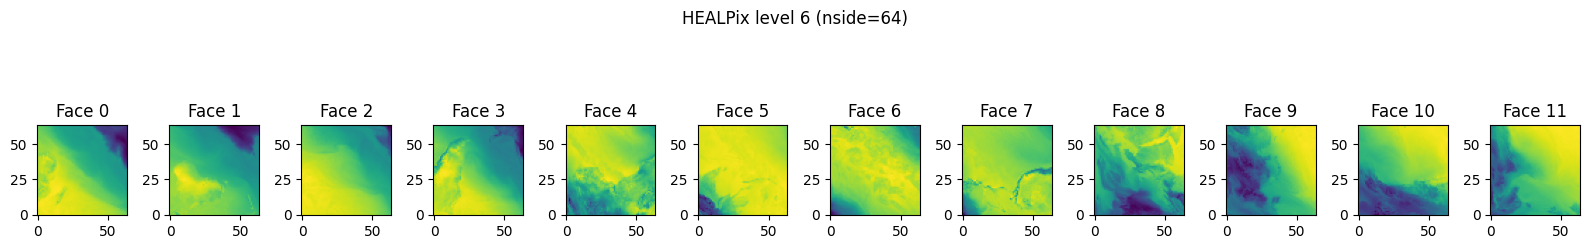

HEALPix regridder ready: 721x1440 -> 12x64x64


In [34]:
# Set up HEALPix regridder (latitude must be ascending)
sample_var = ensure_lat_ascending(ds_atmos.sel(time='2010-01-01T01'))
test_var = list(sample_var.data_vars)[0]
nlat = len(sample_var.latitude)
nlon = len(sample_var.longitude)

src_grid = earth2grid.latlon.equiangular_lat_lon_grid(nlat, nlon)
hpx_grid = earth2grid.healpix.Grid(
    level=HPX_LEVEL, pixel_order=earth2grid.healpix.XY()
)
regridder = earth2grid.get_regridder(src_grid, hpx_grid)

def to_healpix(channel_stack):
    """Convert [C, lat, lon] tensor to [C, 12, nside, nside] HEALPix."""
    return torch.stack(
        [regridder(ch.double()).reshape(12, NSIDE, NSIDE).float()
         for ch in channel_stack],
        dim=0,
    )

# Quick test
test_da = sample_var[test_var]
if test_da.ndim > 2:
    test_da = test_da.isel({d: 0 for d in test_da.dims if d not in ["latitude", "longitude"]})
test_hpx = regridder(torch.tensor(test_da.values, dtype=torch.float64))
test_hpx = test_hpx.reshape(12, NSIDE, NSIDE).float()

fig, axes = plt.subplots(1, 12, figsize=(16, 3))
for i in range(12):
    axes[i].imshow(test_hpx[i].numpy(), origin="lower")
    axes[i].set_title(f"Face {i}")
plt.suptitle(f"HEALPix level {HPX_LEVEL} (nside={NSIDE})")
plt.tight_layout()
plt.show()
print(f"HEALPix regridder ready: {nlat}x{nlon} -> 12x{NSIDE}x{NSIDE}")

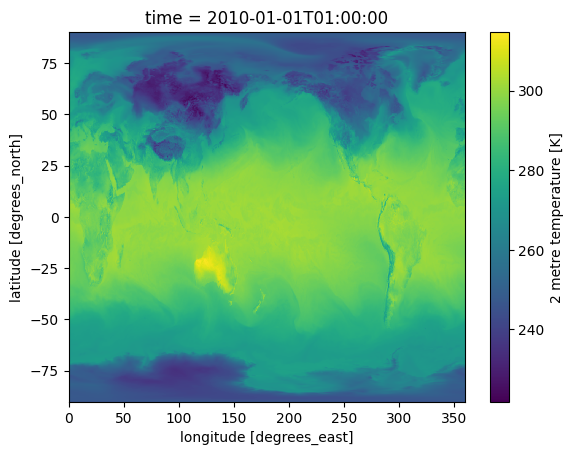

In [47]:
sample_var[test_var].compute().plot()

---
## Step 9: Build X(t) and Y(t+1) for a Single Day

This cell builds one training sample to verify the pipeline end-to-end.

**X(t)** channels (20 total):
- 7 atmos surface: t2m, u10, v10, tcwv, mslp, OLR, TOA solar
- 7 pressure-level: z@1000/850/700/500/300/250, t@850
- 2 land: soil moisture layer 1, soil temperature level 1
- 2 ocean: potential temperature, salinity (level 0)
- 2 static: land-sea mask, elevation

**Y(t+1)** channels (14 total): same 7 surface + 7 pressure-level for the next day.

In [35]:
def build_sample_for_day(date_t_str, date_t1_str, date_t2_str):
    """
    Build normalized HEALPix tensors for a single day transition.

    Args:
        date_t_str:  Date string for day t   (input day)
        date_t1_str: Date string for day t+1 (target day)
        date_t2_str: Date string for day t+2 (end of slice window)

    Returns:
        xb: [1, 20, 12, nside, nside] input tensor
        yb: [1, 14, 12, nside, nside] target tensor
    """
    # -- Daily-mean datasets --
    atm_window = ensure_lat_ascending(
        ds_atmos.sel(time=slice(date_t_str, date_t2_str))
    )
    ds_atm_daily = daily_mean(atm_window)
    ds_atm_t  = pick_single_day(ds_atm_daily, date_t_str)
    ds_atm_t1 = pick_single_day(ds_atm_daily, date_t1_str)

    lnd_window = ensure_lat_ascending(
        ds_land.sel(time=slice(date_t_str, date_t1_str))
    )
    ds_lnd_daily = daily_mean(lnd_window)
    ds_lnd_t = pick_single_day(ds_lnd_daily, date_t_str)

    ds_ocn_t = ocean_nearest_prior(
        ensure_lat_ascending(ds_ocean_regridded), date_t_str
    )

    # -- Reference grid --
    ref_lat = ds_atm_t.latitude
    ref_lon = ds_atm_t.longitude

    def align(da2d):
        return da2d.interp(latitude=ref_lat, longitude=ref_lon, method="linear")

    # -- Resolve variable names --
    GEOPO = resolve_var(ds_atm_t, ["geopotential", "z"])
    TEMP  = resolve_var(ds_atm_t, ["temperature", "t"])

    ATM_2D = [
        (resolve_var(ds_atm_t, ["2m_temperature", "t2m"]),          "2m_temperature"),
        (resolve_var(ds_atm_t, ["10m_u_component_of_wind", "u10"]), "10m_u_component_of_wind"),
        (resolve_var(ds_atm_t, ["10m_v_component_of_wind", "v10"]), "10m_v_component_of_wind"),
        (resolve_var(ds_atm_t, ["total_column_water_vapour", "tcwv"]), "tcwv"),
        (resolve_var(ds_atm_t, ["mean_sea_level_pressure", "msl", "mslp"]), "mean_sea_level_pressure"),
        (resolve_var(ds_atm_t, ["top_net_thermal_radiation", "ttr"]), "top_net_thermal_radiation"),
        (resolve_var(ds_atm_t, ["toa_incident_solar_radiation", "tisr", "toa_insolation"]), "toa_incident_solar_radiation"),
    ]

    ATM_PLEV = [
        (GEOPO, 1000, "z_1000"),
        (GEOPO,  850, "z_850"),
        (GEOPO,  700, "z_700"),
        (GEOPO,  500, "z_500"),
        (GEOPO,  300, "z_300"),
        (GEOPO,  250, "z_250"),
        (TEMP,   850, "t_850"),
    ]

    LND = [
        (resolve_var(ds_lnd_t, ["volumetric_soil_water_layer_1", "swvl1"]), "volumetric_soil_water_layer_1"),
        (resolve_var(ds_lnd_t, ["soil_temperature_level_1", "stl1"]),      "soil_temperature_level_1"),
    ]

    OCN = [
        (resolve_var(ds_ocn_t, ["potential_temperature"]), "potential_temperature"),
        (resolve_var(ds_ocn_t, ["salinity"]),              "salinity"),
    ]

    STAT = [("mask", "landseamask"), ("topo", "elevation")]

    # -- Prepare static dataset --
    ds_stat = ensure_lat_ascending(xr.Dataset({
        "mask": ds_mask["landseamask"],
        "topo": ds_topo["elevation"],
    }))

    # -- Helper to process a 2D field --
    def process_2d(da, norm_key, convert_gph=False):
        da = to_2d(da)
        if convert_gph:
            da = da / G0
        da = fill_latlon_nans_2d(align(da))
        return torch.tensor(norm_minmax(da.values, norm_key), dtype=torch.float32)

    # -- Build X(t): 20 channels --
    X_ch = []
    for ds_name, norm_key in ATM_2D:
        X_ch.append(process_2d(ds_atm_t[ds_name], norm_key))

    for base_var, hpa, norm_key in ATM_PLEV:
        da = select_pressure_level(ds_atm_t[base_var], hpa)
        X_ch.append(process_2d(da, norm_key,
                               convert_gph=(base_var == GEOPO and CONVERT_GPH_TO_HEIGHT)))

    for ds_name, norm_key in LND:
        X_ch.append(process_2d(ds_lnd_t[ds_name], norm_key))

    for ds_name, norm_key in OCN:
        da = ds_ocn_t[ds_name]
        if "level" in da.dims:
            da = da.isel(level=0)
        X_ch.append(process_2d(da, norm_key))

    for v_stat, norm_key in STAT:
        X_ch.append(process_2d(ds_stat[v_stat], norm_key))

    X_ll = torch.stack(X_ch, dim=0)  # [20, lat, lon]

    # -- Build Y(t+1): 14 channels (atmos only) --
    Y_ch = []
    for ds_name, norm_key in ATM_2D:
        Y_ch.append(process_2d(ds_atm_t1[ds_name], norm_key))

    for base_var, hpa, norm_key in ATM_PLEV:
        da = select_pressure_level(ds_atm_t1[base_var], hpa)
        Y_ch.append(process_2d(da, norm_key,
                               convert_gph=(base_var == GEOPO and CONVERT_GPH_TO_HEIGHT)))

    Y_ll = torch.stack(Y_ch, dim=0)  # [14, lat, lon]

    # -- Convert to HEALPix --
    X_hpx = to_healpix(X_ll)  # [20, 12, nside, nside]
    Y_hpx = to_healpix(Y_ll)  # [14, 12, nside, nside]

    return X_hpx.unsqueeze(0), Y_hpx.unsqueeze(0)


# Test with a single day
xb, yb = build_sample_for_day("2025-01-05", "2025-01-06", "2025-01-07")
print(f"xb shape: {xb.shape}  (expect [1, 20, 12, {NSIDE}, {NSIDE}])")
print(f"yb shape: {yb.shape}  (expect [1, 14, 12, {NSIDE}, {NSIDE}])")
print(f"xb range: [{xb.min():.3f}, {xb.max():.3f}]")
print(f"yb range: [{yb.min():.3f}, {yb.max():.3f}]")

xb shape: torch.Size([1, 20, 12, 64, 64])  (expect [1, 20, 12, 64, 64])
yb shape: torch.Size([1, 14, 12, 64, 64])  (expect [1, 14, 12, 64, 64])
xb range: [-3.423, 2.070]
yb range: [-3.423, 0.960]


In [37]:
type(xb)

torch.Tensor

In [40]:
torch.sum(torch.isnan(xb))

tensor(0)

In [41]:
torch.sum(torch.isnan(yb))

tensor(0)

In [42]:
ds_ocean_regridded

<xarray.Dataset> Size: 664MB
Dimensions:                (time: 1, level: 40, latitude: 721, longitude: 1440)
Coordinates:
  * time                   (time) datetime64[s] 8B 2025-01-05
  * level                  (level) int64 320B 5 15 25 35 ... 3016 3483 3972 4478
  * latitude               (latitude) float32 3kB 90.0 89.75 ... -89.75 -90.0
  * longitude              (longitude) float32 6kB 0.0 0.25 0.5 ... 359.5 359.8
Data variables:
    potential_temperature  (time, level, latitude, longitude) float64 332MB n...
    salinity               (time, level, latitude, longitude) float64 332MB n...

---
## Step 10: Define the Diffusion Model

Using HuggingFace `diffusers` UNet3DConditionModel:
- **Input**: noisy Y(t+1) concatenated with X(t) along channel dim = 34 channels
- **Output**: predicted noise in Y space = 14 channels
- Scheduler: LCMScheduler (1000 timesteps)

In [43]:
from diffusers import UNet3DConditionModel, LCMScheduler

COND_CHANNELS   = 20  # X(t)
TARGET_CHANNELS = 14  # Y(t+1)
CROSS_ATTN_DIM  = 1   # dummy (not using text conditioning)

model = UNet3DConditionModel(
    sample_size=None,
    in_channels=TARGET_CHANNELS + COND_CHANNELS,  # 34: noisy_Y + X
    out_channels=TARGET_CHANNELS,                  # 14: predict noise
    layers_per_block=2,
    block_out_channels=(64, 128, 256, 512),
    down_block_types=("DownBlock3D", "DownBlock3D", "DownBlock3D", "DownBlock3D"),
    up_block_types=("UpBlock3D", "UpBlock3D", "UpBlock3D", "UpBlock3D"),
    norm_num_groups=8,
    cross_attention_dim=CROSS_ATTN_DIM,
    attention_head_dim=8,
).to(device)

noise_scheduler = LCMScheduler(num_train_timesteps=1000)
loss_fn = nn.MSELoss()
optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-2)

# Dummy encoder hidden states (cross-attention not meaningfully used)
encoder_hidden_states = torch.zeros(1, 1, CROSS_ATTN_DIM, device=device)

total_params = sum(p.numel() for p in model.parameters())
print(f"Model parameters: {total_params:,}")
print(f"Input channels:  {TARGET_CHANNELS + COND_CHANNELS} (noisy_Y + X)")
print(f"Output channels: {TARGET_CHANNELS} (predicted noise)")

Model parameters: 93,922,126
Input channels:  34 (noisy_Y + X)
Output channels: 14 (predicted noise)


---
## Step 11: Single Training Step (Sanity Check)

Verify the forward/backward pass works before running the full loop.

In [44]:
model.train()

x = xb.to(device)  # conditioning X(t)
y = yb.to(device)  # target Y(t+1)

# 1) Sample noise
noise = torch.randn_like(y)

# 2) Random diffusion timestep
timesteps = torch.randint(
    0, noise_scheduler.config.num_train_timesteps, (1,), device=device
).long()

# 3) Add noise to target
noisy_y = noise_scheduler.add_noise(y, noise, timesteps)

# 4) Concatenate noisy target + conditioning
net_input = torch.cat([noisy_y, x], dim=1)  # [1, 34, 12, 64, 64]

# 5) Predict noise
noise_pred = model(
    sample=net_input,
    timestep=timesteps,
    encoder_hidden_states=encoder_hidden_states,
).sample

# 6) Loss + backward
loss = loss_fn(noise_pred, noise)
optimizer.zero_grad(set_to_none=True)
loss.backward()
optimizer.step()

print(f"Sanity check passed! Loss: {loss.item():.6f}")
print(f"  net_input:  {net_input.shape}")
print(f"  noise_pred: {noise_pred.shape}")

del x, y, noise, noisy_y, net_input, noise_pred, loss
if torch.cuda.is_available():
    torch.cuda.empty_cache()
gc.collect();

Sanity check passed! Loss: 1.129163
  net_input:  torch.Size([1, 34, 12, 64, 64])
  noise_pred: torch.Size([1, 14, 12, 64, 64])


---
## Step 12: Multi-Day Training Loop

Train over consecutive days. Each day:
1. Build X(t), Y(t+1) from ERA5 daily means
2. Run N diffusion training steps
3. Save best model checkpoint

Adjust `YEAR`, `START_DOY`, `END_DOY` for your data availability.

In [20]:
# ==================== TRAINING CONFIG ====================
YEAR = 2018
START_DOY = 1     # day-of-year to start
END_DOY   = 10    # day-of-year to end (exclusive) -- small range for testing
EPOCHS_PER_DAY = 5

best_loss = float("inf")
best_model_path = "best_diffusion_atmos_model.pth"

# ==================== TRAINING LOOP ====================
model.train()
step = 0

for doy in range(START_DOY, END_DOY):
    date_t  = datetime.date(YEAR, 1, 1) + datetime.timedelta(days=doy - 1)
    date_t1 = date_t + datetime.timedelta(days=1)
    date_t2 = date_t + datetime.timedelta(days=2)

    date_t_str  = date_t.isoformat()
    date_t1_str = date_t1.isoformat()
    date_t2_str = date_t2.isoformat()

    print(f"\nDay {doy}: {date_t_str} -> {date_t1_str}")

    try:
        xb_day, yb_day = build_sample_for_day(date_t_str, date_t1_str, date_t2_str)
    except Exception as e:
        print(f"  SKIP day {doy}: {e}")
        continue

    x = xb_day.to(device)
    y = yb_day.to(device)

    for epoch in range(1, EPOCHS_PER_DAY + 1):
        noise = torch.randn_like(y)
        timesteps = torch.randint(
            0, noise_scheduler.config.num_train_timesteps, (1,), device=device
        ).long()
        noisy_y = noise_scheduler.add_noise(y, noise, timesteps)
        net_input = torch.cat([noisy_y, x], dim=1)

        noise_pred = model(
            sample=net_input,
            timestep=timesteps,
            encoder_hidden_states=encoder_hidden_states,
        ).sample

        loss = loss_fn(noise_pred, noise)
        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        optimizer.step()

        loss_val = loss.item()
        step += 1
        print(f"  [Day {doy}] Epoch {epoch:02d} - Loss: {loss_val:.6f}")

        if loss_val < best_loss:
            best_loss = loss_val
            torch.save(model.state_dict(), best_model_path)
            print(f"  Saved best model (loss={best_loss:.6f})")

        del noise, noisy_y, net_input, noise_pred, loss

    del x, y, xb_day, yb_day
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    gc.collect()

print(f"\nTraining complete. Best loss: {best_loss:.6f}")
print(f"Model saved to: {best_model_path}")


Day 1: 2018-01-01 -> 2018-01-02
  SKIP day 1: "not all values found in index 'time'"

Day 2: 2018-01-02 -> 2018-01-03
  SKIP day 2: "not all values found in index 'time'"

Day 3: 2018-01-03 -> 2018-01-04
  SKIP day 3: "not all values found in index 'time'"

Day 4: 2018-01-04 -> 2018-01-05
  SKIP day 4: "not all values found in index 'time'"

Day 5: 2018-01-05 -> 2018-01-06
  SKIP day 5: "not all values found in index 'time'"

Day 6: 2018-01-06 -> 2018-01-07
  SKIP day 6: "not all values found in index 'time'"

Day 7: 2018-01-07 -> 2018-01-08
  SKIP day 7: "not all values found in index 'time'"

Day 8: 2018-01-08 -> 2018-01-09
  SKIP day 8: "not all values found in index 'time'"

Day 9: 2018-01-09 -> 2018-01-10
  SKIP day 9: "not all values found in index 'time'"

Training complete. Best loss: inf
Model saved to: best_diffusion_atmos_model.pth


---
## Step 13: Save to Google Drive (Optional)

In [22]:
# from google.colab import drive
# drive.mount("/content/drive", force_remount=True)

# import shutil
# save_dir = "/content/drive/MyDrive/ai_s2s_checkpoints"
# os.makedirs(save_dir, exist_ok=True)

# shutil.copy(best_model_path, os.path.join(save_dir, best_model_path))
# print(f"Model saved to Google Drive: {save_dir}/{best_model_path}")